In [1]:
import nibabel

from mri_loader import Subject, MRI
from nilearn.glm.first_level import FirstLevelModel

import pandas as pd
import numpy as np

from stats import *




In [2]:
# for meet: maybe event time != process time

subject_ids = set(range(1, 34))
subject_ids -= {1, 3, 13, 22, 32, 33}  # fucked data

subject_ids -= set(range(27, 34))  # exclude SCZ

# subject_ids = list(subject_ids)

run_ids = list(range(1,5))

print(subject_ids, run_ids)

{2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26} [1, 2, 3, 4]


In [3]:

exclude_inflexion = set()


for subject in subject_ids:
    try:
        dataset = Subject(subject, run_ids)

        low_inflexion, high_inflexion = dataset.compute_inflexions()

        if low_inflexion < 0.2 or high_inflexion > 0.8:
            exclude_inflexion.add(subject)
    except:
        exclude_inflexion.add(subject)
        continue



In [4]:
exclude_inflexion

{7, 8, 10, 12, 16, 18, 20, 21, 23, 24, 25, 26}

In [5]:
subject_ids -= exclude_inflexion

subject_ids

{2, 4, 5, 6, 9, 11, 14, 15, 17, 19}

In [6]:
len(subject_ids)

10

In [7]:

global_z_map = {}

contrast_list = [{"+": ["high"], "-": ["low"]},  # high > low
                 {"+": ["undecided"], "-": ["high", "low"]},]  # undecided > high + low

scale = [["25", "35"], ["35", "45"], ["45", "55"], ["55", "65"], ["65", "75"], ["75", "85"], ["85", "95"]]
to_subtract = {"-": ["5", "15"]}

for values in scale:
    contrast_list.append({
        "+": values,
        **to_subtract
    })

for classes in contrast_list:
    name = contrast_name(classes)
    global_z_map[name] = []

global_z_map

{'high > low': [],
 'undecided > high + low': [],
 '25 + 35 > 5 + 15': [],
 '35 + 45 > 5 + 15': [],
 '45 + 55 > 5 + 15': [],
 '55 + 65 > 5 + 15': [],
 '65 + 75 > 5 + 15': [],
 '75 + 85 > 5 + 15': [],
 '85 + 95 > 5 + 15': []}

In [8]:

skipped = []

for subject in subject_ids:

    try:
        dataset = Subject(subject, run_ids)
        dataset.load()

        images, times, labels = dataset.get_data()
        low_inflexion, high_inflexion = dataset.compute_inflexions()
    except Exception as e:
        print("Skipping subject ", subject)
        print(e)
        skipped.append(subject)
        continue

    print(f"{subject=} {low_inflexion=}, {high_inflexion=}")

    labels_class = set(labels)

    events = pd.DataFrame(
        {'onset': times,
         'trial_type': labels,
         'duration': 2.5}
    )

    repetition_time = dataset.repetition_time
    fmri_glm = FirstLevelModel(t_r=repetition_time,
              drift_model='polynomial',
              drift_order=3,
              hrf_model='spm',
              mask_img=dataset.brain_mask,
              smoothing_fwhm=3,
              n_jobs=-1)

    fmri_glm = fmri_glm.fit(images, events)

    design_matrix = fmri_glm.design_matrices_[0]

    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        str(column): contrast_matrix[i]
        for i, column in enumerate(design_matrix.columns)
    }

    low_contrast_columns = []
    high_contrast_columns = []
    undecided_contrast_columns = []

    for key, column in contrasts.items():
        try:
            key_numeric = float(key) / 100

            if key_numeric < low_inflexion:
                low_contrast_columns.append(column)

            elif key_numeric > high_inflexion:
                high_contrast_columns.append(column)

            else:
                undecided_contrast_columns.append(column)

        except ValueError:
            continue

    contrasts["low"]       = np.sum(low_contrast_columns, axis=0)
    contrasts["high"]      = np.sum(high_contrast_columns, axis=0)
    contrasts["undecided"] = np.sum(undecided_contrast_columns, axis=0)

    for contrast in contrast_list:

        glm_contrast_vector  = np.sum(contrasts[column] for column in contrast["+"])
        glm_contrast_vector -= np.sum(contrasts[column] for column in contrast["-"])

        z_score = fmri_glm.compute_contrast(glm_contrast_vector, output_type="z_score")
        name = contrast_name(contrast)

        global_z_map[name].append(z_score)




subject=2 low_inflexion=np.float64(0.2698198198198198), high_inflexion=np.float64(0.613063063063063)
subject=4 low_inflexion=np.float64(0.3202702702702702), high_inflexion=np.float64(0.7229729729729729)
subject=5 low_inflexion=np.float64(0.2554054054054054), high_inflexion=np.float64(0.768018018018018)
subject=6 low_inflexion=np.float64(0.2734234234234234), high_inflexion=np.float64(0.7103603603603603)
subject=9 low_inflexion=np.float64(0.2806306306306306), high_inflexion=np.float64(0.3842342342342342)
subject=11 low_inflexion=np.float64(0.2905405405405405), high_inflexion=np.float64(0.7076576576576576)
subject=14 low_inflexion=np.float64(0.20045045045045046), high_inflexion=np.float64(0.7977477477477477)
subject=15 low_inflexion=np.float64(0.25360360360360357), high_inflexion=np.float64(0.6527027027027027)
subject=17 low_inflexion=np.float64(0.2734234234234234), high_inflexion=np.float64(0.7490990990990991)
subject=19 low_inflexion=np.float64(0.24189189189189186), high_inflexion=np.fl

In [9]:
from nilearn.reporting import get_clusters_table
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map
from brain_map import find_region_names

from nilearn import datasets

import matplotlib.pyplot as plt


In [10]:
z_map_subjects = set(subject_ids)
z_map_subjects -= set(skipped)

plt.style.use('dark_background')

if False:  # avoid plot each time

    for contrast_name, images in global_z_map.items():
        for z_score, subject in zip(images, z_map_subjects):

            clean_z, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="bonferroni", cluster_threshold=5)
            cut_coords_list = [
                (0, 0, 0),
                (10, -20, 30),
                (-15, 10, 45),
            ]

            n_coords = len(cut_coords_list)

            fig, axes = plt.subplots(
                n_coords, 1,
                figsize=(15, 4 * n_coords)
            )

            fig.suptitle(contrast_name, fontweight="bold")

            bg_run = MRI(subject, 1)

            for ax, coords in zip(axes, cut_coords_list):
                plot_stat_map(
                    clean_z,
                    display_mode='ortho',
                    cut_coords=coords,
                    axes=ax,
                    bg_img=bg_run.background,
                    title=f"Ortho @ {coords}",
                    colorbar=True
                )

            plt.tight_layout()
            fname = contrast_name.replace(' ', '_').replace('>', 'over')
            plt.savefig(f"graphs/contrasts/sub-{subject}-contrast-{fname}.png")

In [23]:

atlas_name = 'cort-maxprob-thr0-1mm'
harvard = datasets.fetch_atlas_harvard_oxford(atlas_name=atlas_name)

atlas_img = harvard.maps
labels = harvard.labels

regions_activated = {}

for contrast_name, images in global_z_map.items():
    regions_activated[contrast_name] = []

    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.01, height_control="bonferroni", cluster_threshold=5)
        table = get_clusters_table(
            clean, stat_threshold=threshold, cluster_threshold=5
        )

        pos = [(x,y,z) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

        try:
            indexes, regions_names = find_region_names(pos, atlas_img, labels=labels)
        except Exception as e:
            print(e)
            continue

        regions_names = list(set(str(v) for v in regions_names))

        regions_activated[contrast_name].append(regions_names)

        print(f"{contrast_name=}, {regions_names=}")


[fetch_atlas_harvard_oxford] Dataset found in C:\Users\ducat\nilearn_data\fsl

contrast_name='high > low', regions_names=[]
contrast_name='high > low', regions_names=[]
contrast_name='high > low', regions_names=[]
contrast_name='high > low', regions_names=['Middle Temporal Gyrus, anterior division']
contrast_name='high > low', regions_names=[]
contrast_name='high > low', regions_names=[]
contrast_name='high > low', regions_names=[]
contrast_name='high > low', regions_names=[]
contrast_name='high > low', regions_names=[]
contrast_name='high > low', regions_names=[]
contrast_name='undecided > high + low', regions_names=[]
contrast_name='undecided > high + low', regions_names=[]
contrast_name='undecided > high + low', regions_names=[]
contrast_name='undecided > high + low', regions_names=[]
contrast_name='undecided > high + low', regions_names=[]
contrast_name='undecided > high + low', regions_names=[]
contrast_name='undecided > high + low', regions_names=[]
contrast_name='undecided > high + low', regions_names=[]
contrast_name='undecided > high + low', regions_name

In [12]:
import pandas as pd



In [25]:

regions_activated_np = {}
regions_count = {}

for k, v in regions_activated.items():
    regions_activated_np[k] = np.array(v, dtype=object)

    regions_activated_np[k] = np.concatenate(regions_activated[k])

    regions_count[k] = np.unique_counts(regions_activated_np[k])

regions_count

{'high > low': UniqueCountsResult(values=array(['Middle Temporal Gyrus, anterior division'], dtype='<U40'), counts=array([1])),
 'undecided > high + low': UniqueCountsResult(values=array([], dtype=float64), counts=array([], dtype=int64)),
 '25 + 35 > 5 + 15': UniqueCountsResult(values=array([], dtype=float64), counts=array([], dtype=int64)),
 '35 + 45 > 5 + 15': UniqueCountsResult(values=array(['Background'], dtype='<U32'), counts=array([2])),
 '45 + 55 > 5 + 15': UniqueCountsResult(values=array([], dtype=float64), counts=array([], dtype=int64)),
 '55 + 65 > 5 + 15': UniqueCountsResult(values=array(['Background'], dtype='<U32'), counts=array([1])),
 '65 + 75 > 5 + 15': UniqueCountsResult(values=array(['Background',
        'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)',
        'Middle Temporal Gyrus, posterior division'], dtype='<U67'), counts=array([1, 1, 1])),
 '75 + 85 > 5 + 15': UniqueCountsResult(values=array([], dtype=float64), counts=array([], dtype=int64

In [26]:

df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in regions_activated_np.items()]))

for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(6))


--- high > low ---
high > low
Middle Temporal Gyrus, anterior division    1
Name: count, dtype: int64

--- undecided > high + low ---
Series([], Name: count, dtype: int64)

--- 25 + 35 > 5 + 15 ---
Series([], Name: count, dtype: int64)

--- 35 + 45 > 5 + 15 ---
35 + 45 > 5 + 15
Background    2
Name: count, dtype: int64

--- 45 + 55 > 5 + 15 ---
Series([], Name: count, dtype: int64)

--- 55 + 65 > 5 + 15 ---
55 + 65 > 5 + 15
Background    1
Name: count, dtype: int64

--- 65 + 75 > 5 + 15 ---
65 + 75 > 5 + 15
Middle Temporal Gyrus, posterior division                              1
Background                                                             1
Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)    1
Name: count, dtype: int64

--- 75 + 85 > 5 + 15 ---
Series([], Name: count, dtype: int64)

--- 85 + 95 > 5 + 15 ---
Series([], Name: count, dtype: int64)


In [27]:
summary = pd.DataFrame({
    col.replace(' ', ''): df[col].value_counts()
    for col in df.columns
})

summary = summary.fillna(0)

summary

,high>low,undecided>high+low,25+35>5+15,35+45>5+15,45+55>5+15,55+65>5+15,65+75>5+15,75+85>5+15,85+95>5+15
Background,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0.0,0.0
Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex),0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
"Middle Temporal Gyrus, anterior division",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Middle Temporal Gyrus, posterior division",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


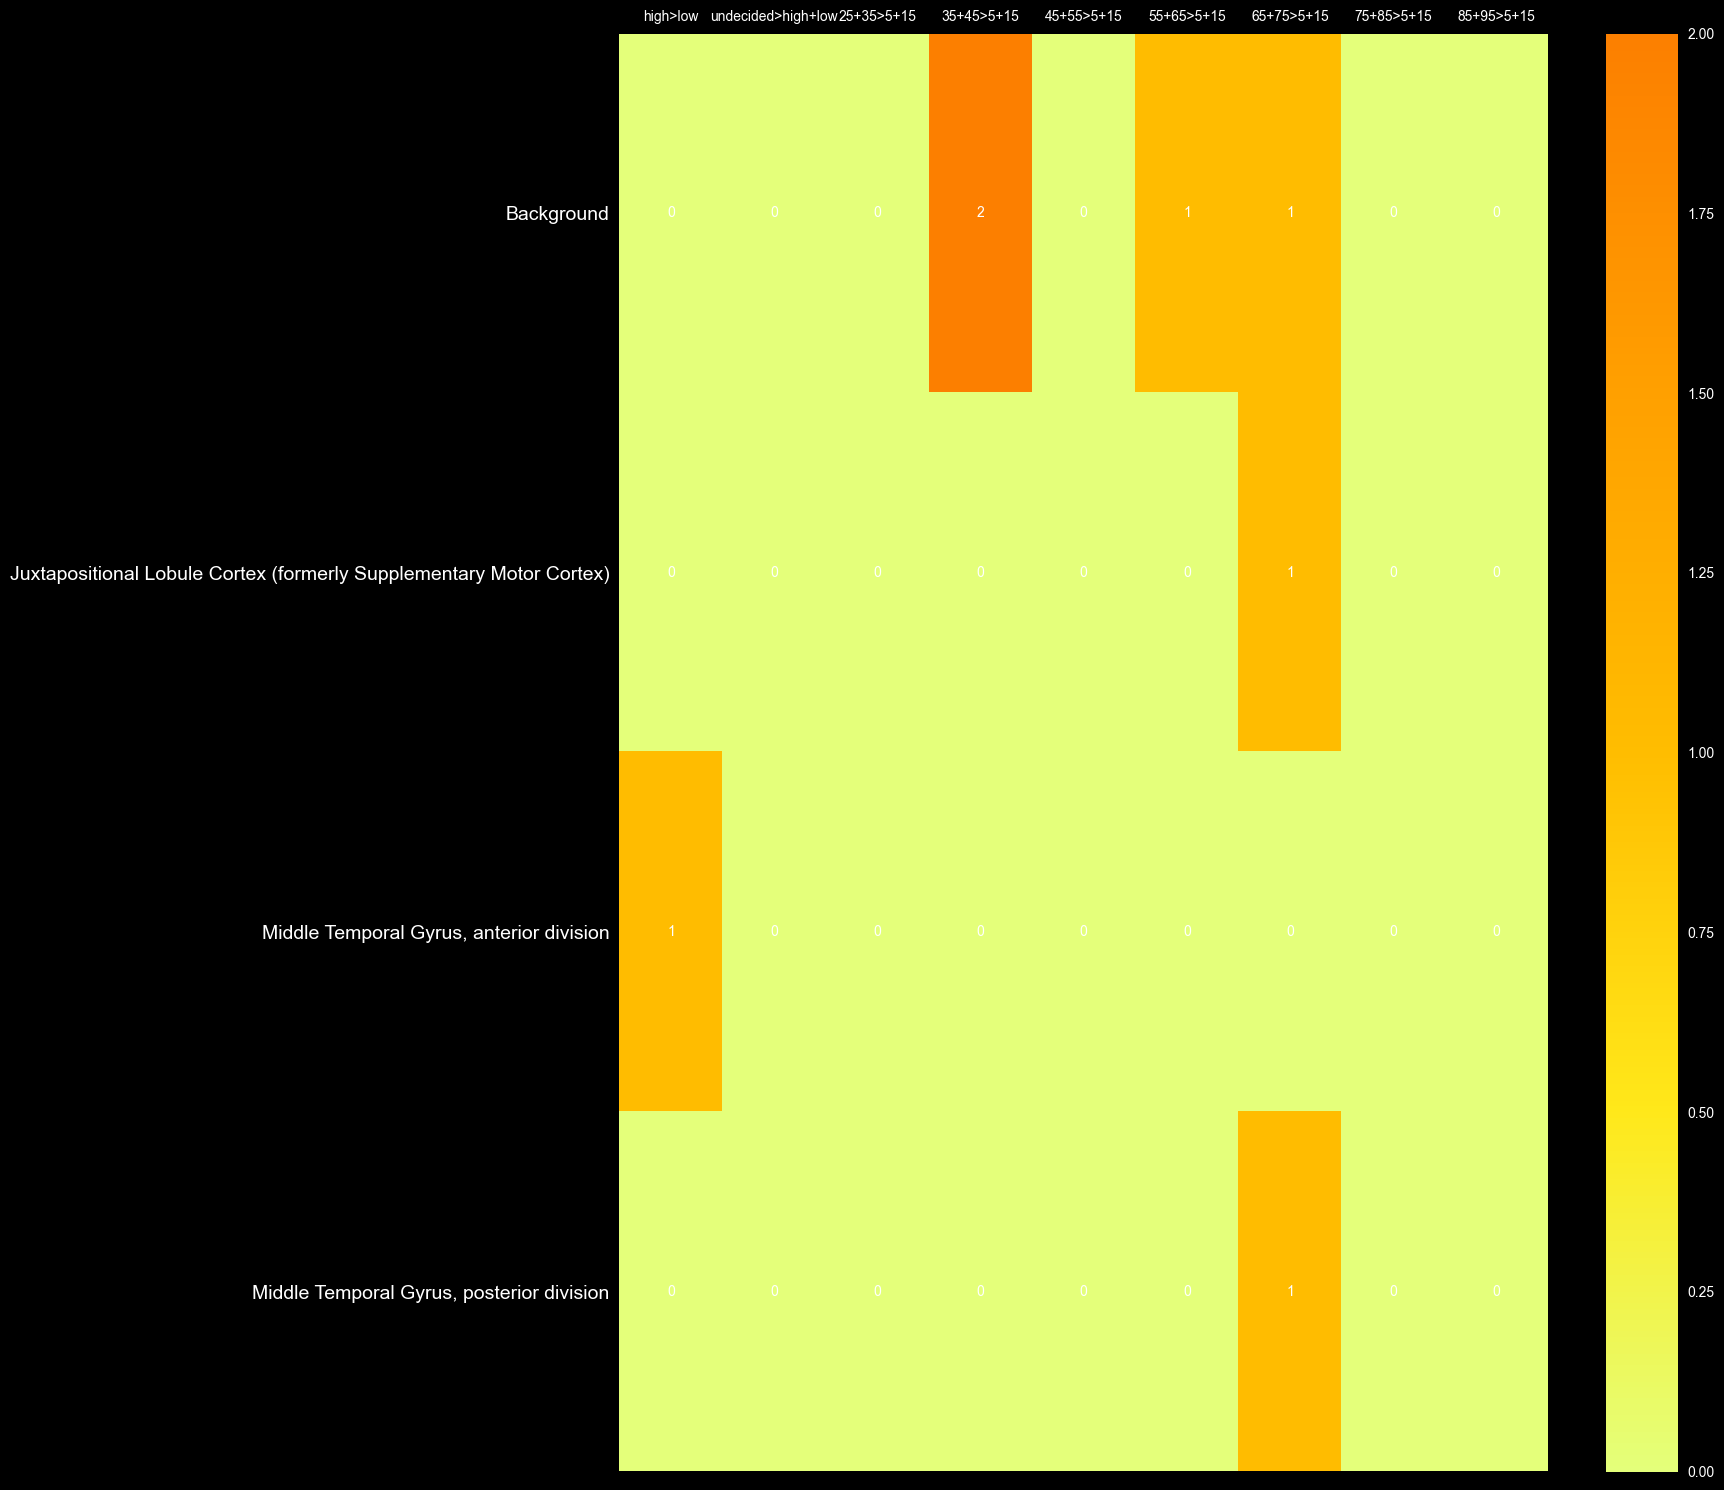

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 15))
im = ax.imshow(summary.values, cmap='Wistia', aspect='auto')

ax.set_xticks(range(len(summary.columns)))
ax.set_yticks(range(len(summary)))
ax.set_xticklabels(summary.columns, fontsize=10)
ax.set_yticklabels(summary.index, fontsize=14)

ax.xaxis.tick_top()

for i in range(len(summary.index)):
    for j in range(len(summary.columns)):
        ax.text(j, i, f'{summary.values[i, j]:.0f}',
                ha='center', va='center', fontsize=10)

ax.grid(False)
ax.tick_params(which='both', length=0)

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [29]:
summary.style.format("{:.0f}").background_gradient(cmap='Blues')

,high>low,undecided>high+low,25+35>5+15,35+45>5+15,45+55>5+15,55+65>5+15,65+75>5+15,75+85>5+15,85+95>5+15
Background,0,0,0,2,0,1,1,0,0
Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex),0,0,0,0,0,0,1,0,0
"Middle Temporal Gyrus, anterior division",1,0,0,0,0,0,0,0,0
"Middle Temporal Gyrus, posterior division",0,0,0,0,0,0,1,0,0


In [18]:
for contrast_name, images in global_z_map.items():
    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.01, height_control="bonferroni", cluster_threshold=5)
        table = get_clusters_table(
            clean, stat_threshold=threshold, cluster_threshold=5
        )

        pos = [(x,y,z) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

        print(pos)

        break

    break


[]


In [19]:
from lib.mni_to_atlas import AtlasBrowser
import numpy as np

atlas = AtlasBrowser("AAL3")



In [33]:
mni_regions = {}

for contrast_name, images in global_z_map.items():
    mni_regions[contrast_name] = []

    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.05, height_control="bonferroni", cluster_threshold=2)
        table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=2)

        pos = [np.array([x,y,z]) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

        for p in pos:
            projected_coords = atlas.project_to_nearest(p)
            projected_regions = atlas.find_regions(projected_coords)

            mni_regions[contrast_name].append(projected_regions)


In [34]:
mni_regions_concat = {}

for k, v in mni_regions.items():

    reg_list = np.array(v, dtype=object)

    mni_regions_concat[k] = np.concatenate(reg_list)

In [35]:
mni_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in mni_regions_concat.items()]))


In [36]:
mni_summary = pd.DataFrame({
    col.replace(' ', ''): mni_df[col].value_counts()
    for col in mni_df.columns
})

mni_summary = mni_summary.fillna(0)

mni_summary

,high>low,undecided>high+low,25+35>5+15,35+45>5+15,45+55>5+15,55+65>5+15,65+75>5+15,75+85>5+15,85+95>5+15
ACC_pre_L,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
ACC_pre_R,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
ACC_sup_L,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Caudate_L,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
Caudate_R,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
Temporal_Pole_Sup_L,0.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,1.0
Temporal_Pole_Sup_R,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
Temporal_Sup_R,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
Thal_PuL_R,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


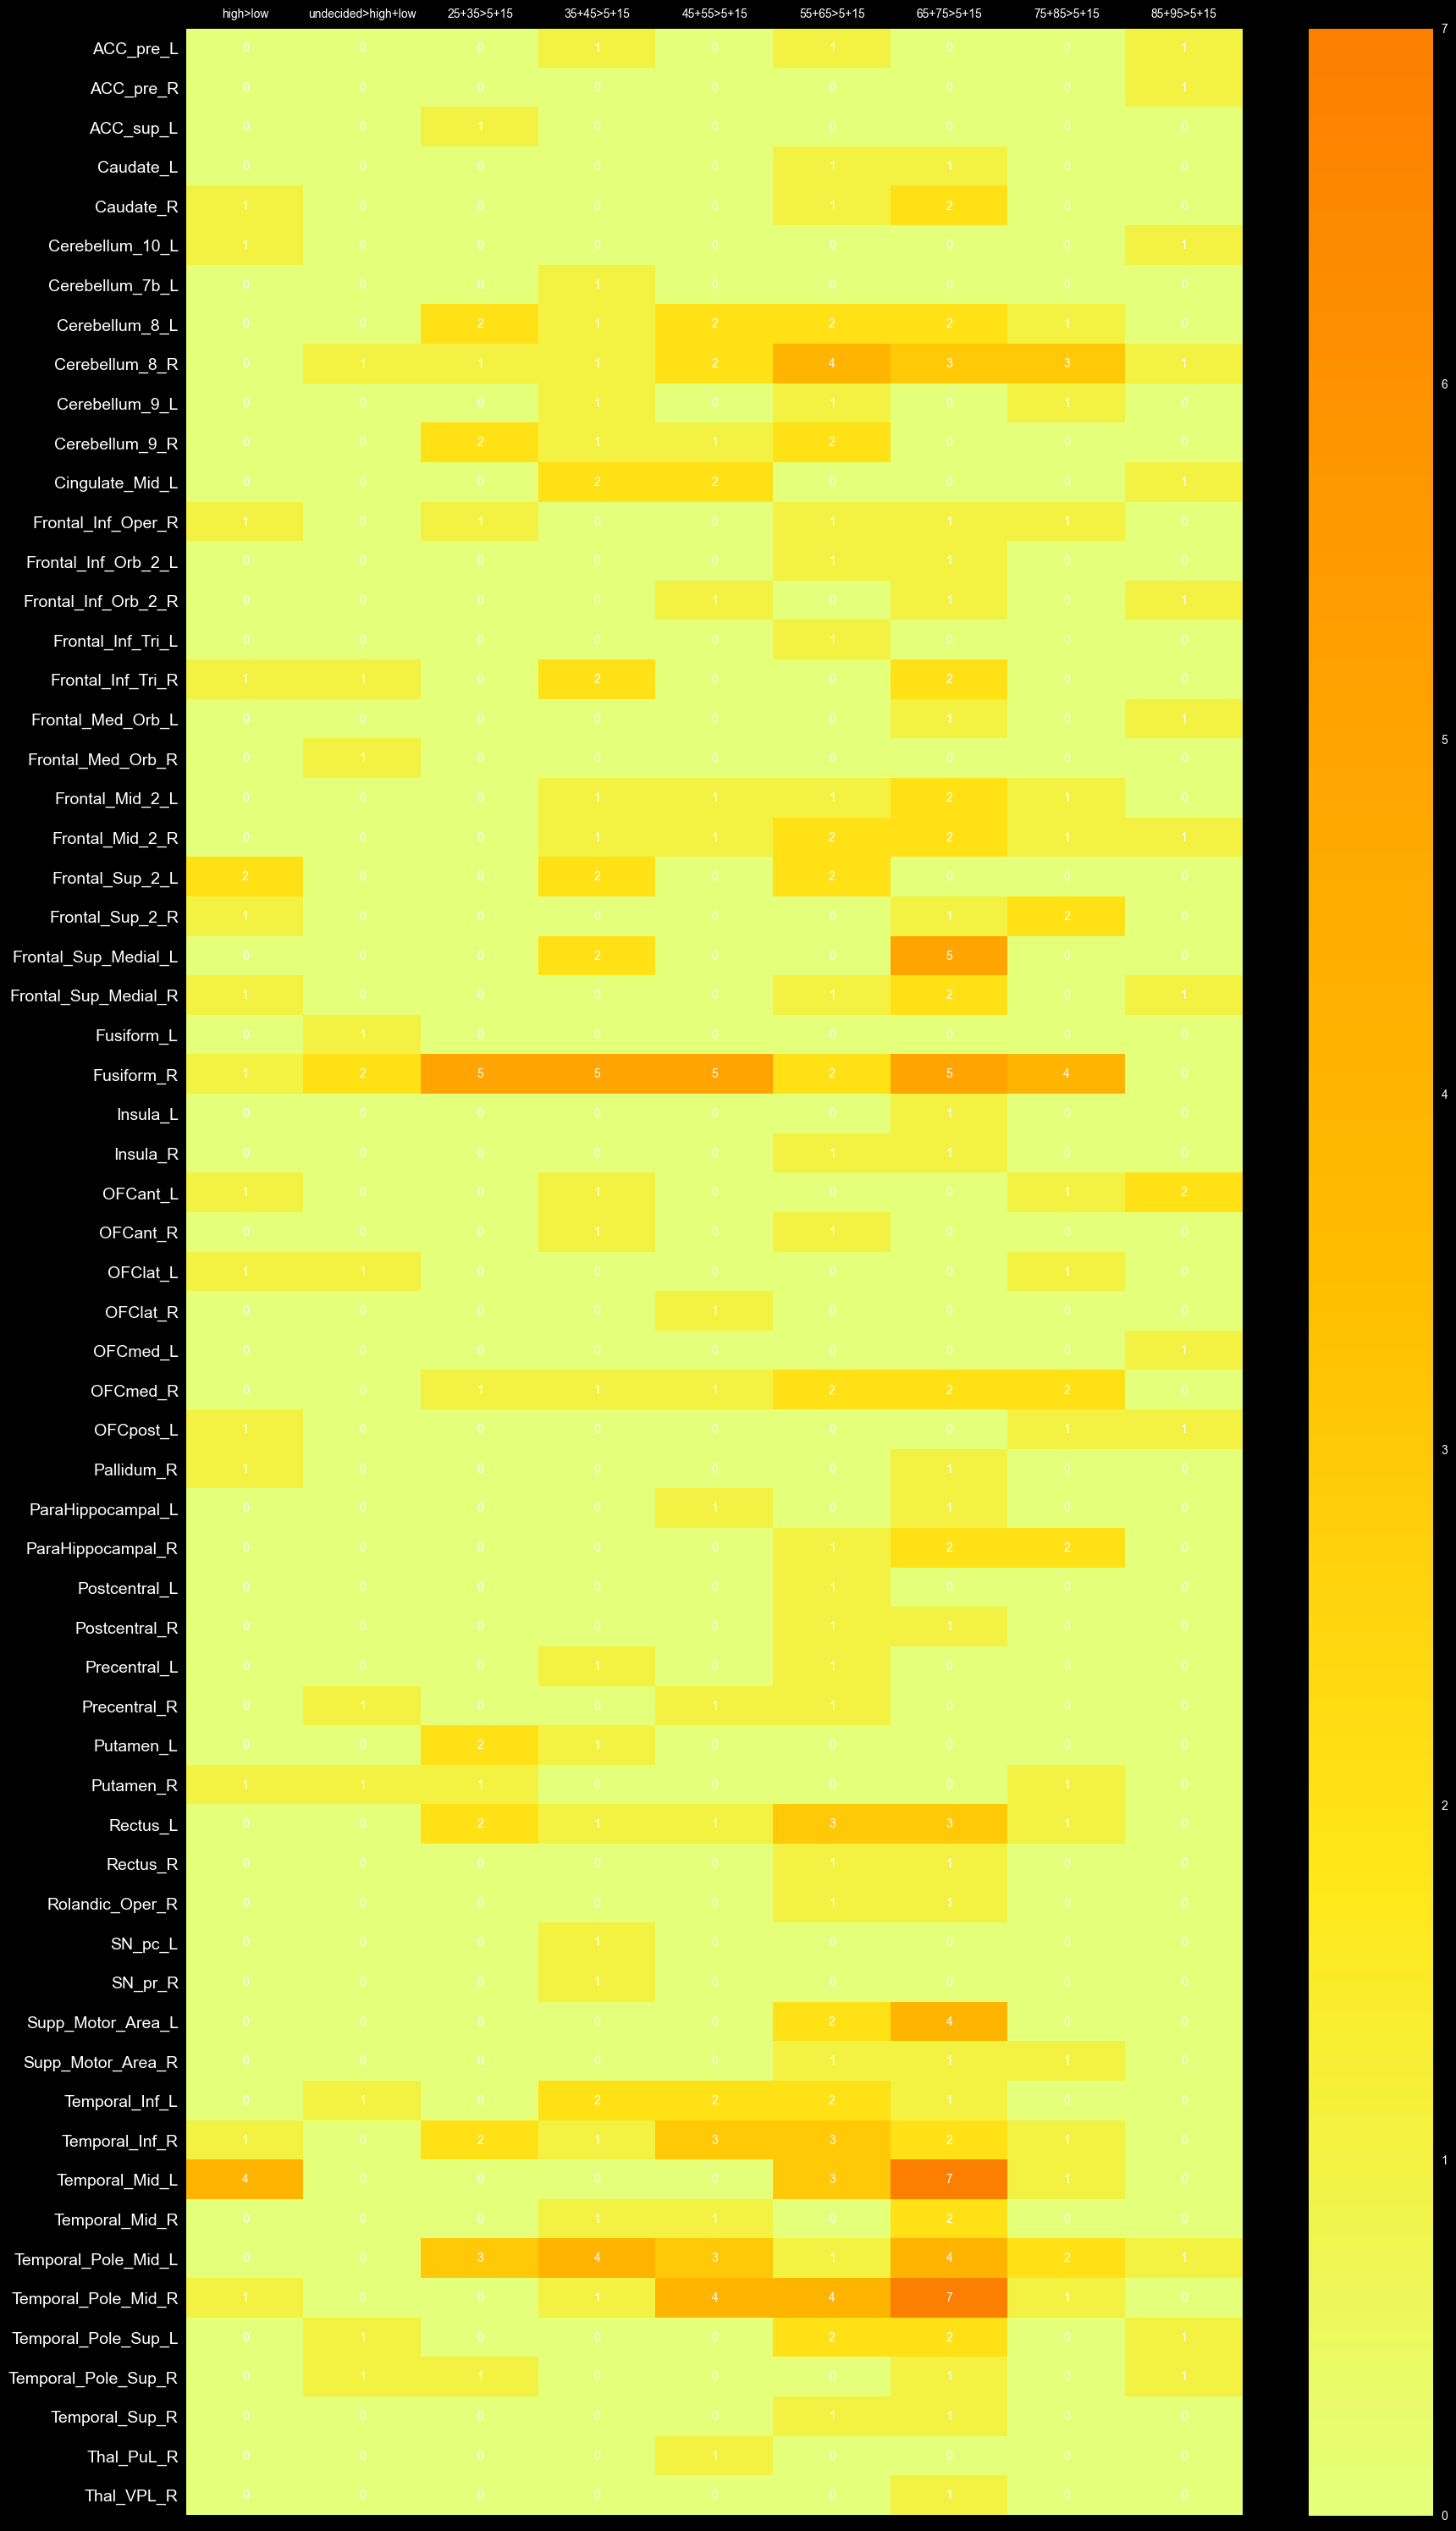

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 30))
im = ax.imshow(mni_summary.values, cmap='Wistia', aspect='auto')

ax.set_xticks(range(len(mni_summary.columns)))
ax.set_yticks(range(len(mni_summary)))
ax.set_xticklabels(mni_summary.columns, fontsize=10)
ax.set_yticklabels(mni_summary.index, fontsize=14)

ax.xaxis.tick_top()

for i in range(len(mni_summary.index)):
    for j in range(len(mni_summary.columns)):
        ax.text(j, i, f'{mni_summary.values[i, j]:.0f}',
                ha='center', va='center', fontsize=10)

ax.grid(False)
ax.tick_params(which='both', length=0)

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [38]:
import nibabel

for contrast_name, images in global_z_map.items():

    for z_score, subject in zip(images, z_map_subjects):

        fname = contrast_name.replace(' ', '_').replace('>', 'over')

        nibabel.save(z_score, f"contrasts/smoothed_3mm/sub-{subject}-{fname}.nii.gz")
